# 09 - DS Diagnostics ModÃ¨le, ExplicabilitÃ©, Robustesse et Storytelling

Objectif: comprendre **pourquoi** le modÃ¨le marche (ou Ã©choue), pas seulement mesurer un score.


**Convention de commentaire dans ce notebook (Ã  respecter dans l'analyse)**

- `Constat` : ce que montrent les chiffres/graphes
- `InterprÃ©tation` : ce que cela signifie (avec prudence)
- `DÃ©cision` : impact pratique sur preprocessing / CV / modÃ¨le
- Terminer chaque bloc par une phrase `Impact modÃ¨le attendu`


In [1]:
import sys
import json
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

NOTEBOOK_DIR = Path.cwd().resolve()
ROOT = NOTEBOOK_DIR
for _candidate in [NOTEBOOK_DIR, *NOTEBOOK_DIR.parents]:
    if (_candidate / "src").exists() and (_candidate / "data").exists():
        ROOT = _candidate
        break
else:
    raise RuntimeError("Project root not found. Expected folders: src/ and data/.")
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
ARTIFACTS_DIR = ROOT / "artifacts"

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
from src.insurance_pricing.training import ensure_dir


import src.insurance_pricing.training as v2
from src.insurance_pricing.analytics import *

DATA_DIR = ROOT / "data"
ARTIFACT_DS = ensure_dir(ROOT / DEFAULT_DS_DIR)
ARTIFACT_V2 = ROOT / v2.DEFAULT_V2_DIR

SEED = 42
QUICK_ANALYSIS = True
FULL_ANALYSIS = False
SAMPLE_N = 3000
np.random.seed(SEED)


In [2]:
print("ARTIFACT_V2 exists:", ARTIFACT_V2.exists())
if ARTIFACT_V2.exists():
    for p in sorted(ARTIFACT_V2.iterdir()):
        if p.is_file():
            print(f"{p.name:<40} {p.stat().st_size/1024:.1f} KB")


ARTIFACT_V2 exists: True
dataset_meta_v2.json                     0.7 KB
ensemble_weights_v2.json                 1.5 KB
feature_set_comparison_v2.csv            3.5 KB
folds_aux_blocked5.parquet               685.9 KB
folds_primary_time.parquet               464.9 KB
folds_secondary_group.parquet            689.7 KB
model_cards_v2.csv                       4.6 KB
objective_screening_v2.csv               8.4 KB
oof_predictions_selected_v2.parquet      226322.5 KB
oof_predictions_v2.parquet               117020.2 KB
pred_distribution_audit_v2.csv           44.4 KB
run_registry_stage1.csv                  20.4 KB
run_registry_stage2.csv                  272.0 KB
run_registry_v2.csv                      21.3 KB
segment_diagnostics_v2.parquet           14.4 KB
selected_models_v2.csv                   2.9 KB
selection_report_v2.csv                  11.6 KB
shakeup_v2_ensemble.parquet              69.1 KB
shakeup_v2_ensemble_tail.parquet         69.1 KB
shakeup_v2_single.parquet             

In [3]:
# Chargement des artefacts V2 (avec fallback)
paths = {
    "run_registry": ARTIFACT_V2 / "run_registry_v2.csv",
    "oof_predictions": ARTIFACT_V2 / "oof_predictions_v2.parquet",
    "selected_models": ARTIFACT_V2 / "selected_models_v2.csv",
    "selection_report": ARTIFACT_V2 / "selection_report_v2.csv",
    "ensemble_weights": ARTIFACT_V2 / "ensemble_weights_v2.json",
    "submission_audit": ARTIFACT_V2 / "submission_audit_v2.json",
    "pred_distribution_audit": ARTIFACT_V2 / "pred_distribution_audit_v2.csv",
}

run_df = pd.read_csv(paths["run_registry"]) if paths["run_registry"].exists() else pd.DataFrame()
oof_df = pd.read_parquet(paths["oof_predictions"]) if paths["oof_predictions"].exists() else pd.DataFrame()
selected_df = pd.read_csv(paths["selected_models"]) if paths["selected_models"].exists() else pd.DataFrame()
selection_report_df = pd.read_csv(paths["selection_report"]) if paths["selection_report"].exists() else pd.DataFrame()
ens_meta = json.loads(paths["ensemble_weights"].read_text(encoding="utf-8")) if paths["ensemble_weights"].exists() else {}
submission_audit = json.loads(paths["submission_audit"].read_text(encoding="utf-8")) if paths["submission_audit"].exists() else {}
pred_dist_df = pd.read_csv(paths["pred_distribution_audit"]) if paths["pred_distribution_audit"].exists() else pd.DataFrame()

print("run_df:", run_df.shape, "oof_df:", oof_df.shape, "selected_df:", selected_df.shape)
display(run_df.head(3))
display(selected_df.head(3))


run_df: (81, 18) oof_df: (8100000, 18) selected_df: (6, 32)


,level,split,feature_set,engine,family,config_id,seed,severity_mode,calibration,tail_mapper,fold_id,n_valid,rmse_prime,auc_freq,brier_freq,rmse_sev_pos,q99_ratio_pos,run_id
0,run,primary_time,base_v2,catboost,two_part_classic,cb_v2_c1,42,classic,none,isotonic,-1,40000,544.609188,0.612200,0.054695,1464.368583,0.310240,base_v2|catboost|two_part_classic|cb_v2_c1|42|...
1,run,primary_time,base_v2,catboost,two_part_classic,cb_v2_c1,42,classic,isotonic,isotonic,-1,40000,544.092828,0.608750,0.054531,1464.368583,0.310240,base_v2|catboost|two_part_classic|cb_v2_c1|42|...
2,run,secondary_group,base_v2,catboost,two_part_classic,cb_v2_c1,42,classic,none,isotonic,-1,50000,541.957024,0.651965,0.054078,1455.708350,0.320485,base_v2|catboost|two_part_classic|cb_v2_c1|42|...


,run_id,feature_set,engine,family,config_id,seed,severity_mode,calibration,tail_mapper,rmse_aux_blocked5,...,tail_penalty,selection_score,accepted_secondary,accepted_aux,accepted_tail,accepted_collapse,accepted_dispersion,accepted,decision_reason,rank
0,base_v2|catboost|two_part_tweedie|cb_v2_c1|42|...,base_v2,catboost,two_part_tweedie,cb_v2_c1,42,weighted_tail,isotonic,isotonic,542.595859,...,0.671267,545.585711,True,True,True,True,True,True,accepted,1
1,base_v2|catboost|two_part_tweedie|cb_v2_c1|42|...,base_v2,catboost,two_part_tweedie,cb_v2_c1,42,classic,isotonic,isotonic,542.571435,...,0.678882,545.732181,True,True,True,True,True,True,accepted,2
2,base_v2|catboost|two_part_classic|cb_v2_c1|42|...,base_v2,catboost,two_part_classic,cb_v2_c1,42,classic,isotonic,isotonic,542.670668,...,0.689760,545.834739,True,True,True,True,True,True,accepted,3


## Rappel du protocole (Ã  prÃ©senter)

- **Split primaire**: `primary_time` (rÃ©fÃ©rence de classement local)
- **Split secondaire**: `secondary_group` sur `id_client` (anti-fuite)
- **Split auxiliaire**: `aux_blocked5` (stress test)
- **OOF**: prÃ©dictions sur validation uniquement, modÃ¨le n'ayant pas vu les lignes
- **Score Kaggle**: RMSE sur la prime prÃ©dite (coÃ»t rÃ©el vs prime)

DÃ©finitions utiles:
- `AUC`, `Gini`, `Brier`, `RÂ²`, `RMSE` (rappels Ã  expliquer Ã  l'oral)


In [4]:
# Baselines indispensables (si OOF dispo)
from src.insurance_pricing.analytics.quality import _rmse


if not oof_df.empty:
    # on prend un split/runs OOF disponible pour obtenir y_true
    d0 = oof_df[(oof_df["is_test"] == 0) & oof_df["y_sev"].notna()].copy()
    if len(d0):
        y_true = d0.groupby("row_idx")["y_sev"].first().sort_index().to_numpy()
        mean_pred = np.full_like(y_true, float(np.mean(y_true)), dtype=float)
        zero_pred = np.zeros_like(y_true, dtype=float)
        pure_const = np.full_like(y_true, float(np.mean(y_true)), dtype=float)
        baseline_df = pd.DataFrame([
            {"baseline": "mean_prime", "rmse": _rmse(y_true, mean_pred)},
            {"baseline": "all_zero", "rmse": _rmse(y_true, zero_pred)},
            {"baseline": "pure_premium_constant", "rmse": _rmse(y_true, pure_const)},
        ])
        display(baseline_df)
    else:
        print("OOF vide -> impossible de recalculer les baselines.")
else:
    print("Artifacts V2 absents -> section baseline en mode descriptif.")


,baseline,rmse
0,mean_prime,545.397425
1,all_zero,555.106812
2,pure_premium_constant,545.397425


In [5]:
# Comparatif moteurs / familles / splits
if not run_df.empty:
    rr = run_df.copy()
    rr = rr[rr["level"] == "run"] if "level" in rr.columns else rr
    cols = [c for c in ["feature_set","engine","family","severity_mode","split","rmse_prime","auc_freq","brier_freq","rmse_sev_pos","q99_ratio_pos","distribution_collapse_flag","tail_dispersion_flag"] if c in rr.columns]
    display(rr[cols].sort_values(["split","rmse_prime"]).head(40))

    summary = rr.pivot_table(
        index=["engine","family","severity_mode"],
        values=[c for c in ["rmse_prime","q99_ratio_pos","distribution_collapse_flag"] if c in rr.columns],
        aggfunc="mean",
    ).sort_values("rmse_prime")
    display(summary.head(20))


,feature_set,engine,family,severity_mode,split,rmse_prime,auc_freq,brier_freq,rmse_sev_pos,q99_ratio_pos
17,base_v2,catboost,two_part_tweedie,classic,aux_blocked5,542.571435,0.635468,0.054255,1461.456772,0.283293
16,base_v2,catboost,two_part_tweedie,classic,aux_blocked5,542.575544,0.638932,0.054260,1461.456772,0.283293
11,base_v2,catboost,two_part_classic,weighted_tail,aux_blocked5,542.577648,0.635468,0.054255,1462.643524,0.297873
10,base_v2,catboost,two_part_classic,weighted_tail,aux_blocked5,542.578502,0.638932,0.054260,1462.643524,0.297873
23,base_v2,catboost,two_part_tweedie,weighted_tail,aux_blocked5,542.595859,0.635468,0.054255,1461.475757,0.298799
22,base_v2,catboost,two_part_tweedie,weighted_tail,aux_blocked5,542.611299,0.638932,0.054260,1461.475757,0.298799
5,base_v2,catboost,two_part_classic,classic,aux_blocked5,542.670668,0.635468,0.054255,1464.672223,0.294504
4,base_v2,catboost,two_part_classic,classic,aux_blocked5,542.681086,0.638932,0.054260,1464.672223,0.294504
77,base_v2,xgboost,two_part_tweedie,weighted_tail,aux_blocked5,542.841891,0.630252,0.054308,1461.418314,0.303062
65,base_v2,xgboost,two_part_classic,weighted_tail,aux_blocked5,542.842109,0.630252,0.054308,1462.489815,0.283711


q99_ratio_pos  rmse_prime
engine   family           severity_mode                           
catboost two_part_tweedie weighted_tail       0.313388  542.968583
         two_part_classic weighted_tail       0.303913  542.994180
         two_part_tweedie classic             0.306377  542.997573
         two_part_classic classic             0.308409  543.015681
xgboost  two_part_classic weighted_tail       0.300106  543.173975
         two_part_tweedie weighted_tail       0.305674  543.184571
                          classic             0.303995  543.185727
         two_part_classic classic             0.319355  543.213443
lightgbm two_part_classic weighted_tail       0.307744  543.405103
catboost direct_tweedie   classic             0.333008  543.442768
lightgbm two_part_classic classic             0.310998  543.445210
         two_part_tweedie classic             0.315481  543.445903
                          weighted_tail       0.291883  543.469590
xgboost  direct_tweedie   classic             0.316589  543.719212
lightgbm direct_tweedie   classic             0.329393  544.076564

In [6]:
# SÃ©lection finale et raisons de rejet / acceptation
if not selection_report_df.empty:
    cols = [c for c in ["run_id","rank","selection_score","accepted","decision_reason","rmse_primary_time","rmse_secondary_group","rmse_aux_blocked5","q99_primary_time","distribution_collapse_flag","tail_dispersion_flag"] if c in selection_report_df.columns]
    display(selection_report_df[cols].head(30))
else:
    print("selection_report_v2.csv absent.")


,run_id,rank,selection_score,accepted,decision_reason,rmse_primary_time,rmse_secondary_group,rmse_aux_blocked5,q99_primary_time,distribution_collapse_flag,tail_dispersion_flag
0,base_v2|catboost|two_part_tweedie|cb_v2_c1|42|...,1,545.585711,True,accepted,543.897946,542.188168,542.595859,0.328733,0.0,0.0
1,base_v2|catboost|two_part_tweedie|cb_v2_c1|42|...,2,545.732181,True,accepted,544.026383,542.170569,542.571435,0.321118,0.0,0.0
2,base_v2|catboost|two_part_classic|cb_v2_c1|42|...,3,545.834739,True,accepted,544.092828,542.083295,542.670668,0.310240,0.0,0.0
3,base_v2|xgboost|two_part_tweedie|xgb_v2_c1|42|...,4,546.014272,True,accepted,544.322745,542.289359,542.888025,0.330594,0.0,0.0
4,base_v2|lightgbm|two_part_classic|lgb_v2_c1|42...,5,546.020444,True,accepted,544.351093,542.725670,543.121771,0.336075,0.0,0.0
5,base_v2|xgboost|two_part_tweedie|xgb_v2_c1|42|...,6,546.021755,True,accepted,544.336071,542.394952,542.883211,0.330594,0.0,0.0
6,base_v2|xgboost|two_part_classic|xgb_v2_c1|42|...,7,546.028749,True,accepted,544.318236,542.482881,542.877905,0.319171,0.0,0.0
7,base_v2|xgboost|two_part_classic|xgb_v2_c1|42|...,8,546.038646,True,accepted,544.315178,542.413056,542.842109,0.314437,0.0,0.0
8,base_v2|xgboost|two_part_classic|xgb_v2_c1|42|...,9,546.040011,True,accepted,544.311147,542.307956,542.854402,0.314437,0.0,0.0
9,base_v2|xgboost|two_part_classic|xgb_v2_c1|42|...,10,546.045743,True,accepted,544.330795,542.384332,542.886507,0.319171,0.0,0.0


In [7]:
# Choix du run de diagnostic principal + runs comparatifs
run_id_main = None
run_diag_ids = []
if not selected_df.empty and "run_id" in selected_df.columns:
    run_id_main = str(selected_df.iloc[0]["run_id"])
    run_diag_ids.append(run_id_main)
if not run_df.empty:
    rr = run_df.copy()
    if "level" in rr.columns:
        rr = rr[rr["level"] == "run"]
    if "split" in rr.columns:
        rr_primary = rr[rr["split"] == "primary_time"].copy()
    else:
        rr_primary = rr.copy()
    if len(rr_primary):
        # meilleur RMSE primaire
        best_rmse_id = str(rr_primary.sort_values("rmse_prime").iloc[0]["run_id"])
        run_diag_ids.append(best_rmse_id)
        # meilleur q99 (couverture queue) parmi scores valides
        if "q99_ratio_pos" in rr_primary.columns:
            qq = rr_primary.copy()
            qq["q99_dist_to_1"] = (qq["q99_ratio_pos"] - 1.0).abs()
            qq = qq[np.isfinite(qq["q99_dist_to_1"])]
            if len(qq):
                run_diag_ids.append(str(qq.sort_values(["q99_dist_to_1", "rmse_prime"]).iloc[0]["run_id"]))
        # meilleur compromis stabilitÃ© si gaps dispo
        if {"rmse_gap_secondary","rmse_gap_aux"}.issubset(rr_primary.columns):
            ss = rr_primary.copy()
            ss["stability_penalty"] = ss[["rmse_gap_secondary","rmse_gap_aux"]].fillna(0.0).abs().sum(axis=1)
            run_diag_ids.append(str(ss.sort_values(["stability_penalty","rmse_prime"]).iloc[0]["run_id"]))
    if run_id_main is None and len(rr_primary):
        run_id_main = str(rr_primary.sort_values("rmse_prime").iloc[0]["run_id"])
run_diag_ids = list(dict.fromkeys([x for x in run_diag_ids if x is not None]))
print("run_id_main:", run_id_main)
print("run_diag_ids:", run_diag_ids)


run_id_main: base_v2|catboost|two_part_tweedie|cb_v2_c1|42|weighted_tail|isotonic|isotonic
run_diag_ids: ['base_v2|catboost|two_part_tweedie|cb_v2_c1|42|weighted_tail|isotonic|isotonic', 'base_v2|catboost|direct_tweedie|cb_v2_c1|42|classic|none|none']


In [8]:
# Diagnostics OOF dÃ©taillÃ©s (mÃ©triques, calibration, dÃ©ciles, rÃ©sidus) + comparatif multi-runs
diag_tables = {}
diag_compare_rows = []
if run_id_main is not None and not oof_df.empty:
    diag_tables = compute_oof_model_diagnostics(oof_df, run_id=run_id_main, split="primary_time", decile_mode="zero_aware")
    for name, df_ in diag_tables.items():
        print(f"[{name}] ->", getattr(df_, "shape", None))
        if isinstance(df_, pd.DataFrame) and len(df_):
            display(df_.head(20))

    # comparatif succinct sur plusieurs runs pour justifier le choix final
    for rid in run_diag_ids[:4]:
        try:
            dt = compute_oof_model_diagnostics(oof_df, run_id=rid, split="primary_time", decile_mode="zero_aware")
            m = dt.get("metrics", pd.DataFrame())
            if not m.empty:
                row = m.iloc[0].to_dict()
                row["run_id"] = rid
                diag_compare_rows.append(row)
        except Exception as e:
            diag_compare_rows.append({"run_id": rid, "diagnostic_error": f"{type(e).__name__}: {e}"})
    diag_compare_df = pd.DataFrame(diag_compare_rows)
    if len(diag_compare_df):
        print("Comparatif diagnostics (primary_time):")
        cols = [c for c in ["run_id","rmse_prime","mae_prime","rmse_prime_top1pct","auc_freq","brier_freq","rmse_sev_pos","q95_ratio_pos","q99_ratio_pos","mae_prime_nonzero","r2_prime_nonzero"] if c in diag_compare_df.columns]
        display(diag_compare_df[cols] if cols else diag_compare_df)
else:
    print("OOF ou run_id indisponible.")
    diag_compare_df = pd.DataFrame()


[metrics] -> (1, 20)


,run_id,split,n,n_nonzero,share_nonzero,rmse_prime,mae_prime,r2_prime,auc_freq,gini_freq,brier_freq,logloss_freq,pr_auc_freq,rmse_sev_pos,mae_sev_pos,q95_ratio_pos,q99_ratio_pos,mae_prime_nonzero,r2_prime_nonzero,rmse_prime_top1pct
0,base_v2|catboost|two_part_tweedie|cb_v2_c1|42|...,primary_time,50000,2917,0.05834,545.929482,174.134052,-0.001952,0.594651,0.189301,0.054613,0.21989,0.075693,1662.270082,1106.900817,0.476975,0.32863,1675.786354,-1.308247,4548.227515


[error_by_decile_true] -> (11, 10)


,decile_basis,bin_type,bin_order,bin,n,y_mean,pred_mean,bias,mae,rmse
0,y_true,zero,0,zero,47083,0.000000,81.100053,81.100053,81.100053,100.615752
1,y_true,positive_decile,1,"(600.599, 698.79]",292,644.527500,99.766043,-544.761457,544.930072,550.277253
2,y_true,positive_decile,2,"(698.79, 851.978]",292,772.985342,96.150867,-676.834476,676.834476,680.605112
3,y_true,positive_decile,3,"(851.978, 1010.41]",331,957.972085,88.952121,-869.019963,869.019963,873.282006
4,y_true,positive_decile,4,"(1010.41, 1224.192]",252,1114.050952,98.798698,-1015.252255,1015.252255,1018.862386
5,y_true,positive_decile,5,"(1224.192, 1236.0]",346,1235.759364,75.905501,-1159.853863,1159.853863,1161.232854
6,y_true,positive_decile,6,"(1236.0, 1442.87]",259,1337.212664,100.502512,-1236.710152,1236.710152,1239.942841
7,y_true,positive_decile,7,"(1442.87, 1890.012]",270,1650.654889,97.246145,-1553.408744,1553.408744,1560.494063
8,y_true,positive_decile,8,"(1890.012, 2487.526]",291,2180.740722,102.991911,-2077.748810,2077.748810,2087.066466
9,y_true,positive_decile,9,"(2487.526, 3336.74]",292,2812.897260,102.709318,-2710.187943,2710.187943,2721.394782


[error_by_decile_true_zero_aware] -> (11, 10)


...

,subset,n,share,y_mean,pred_mean,mae,rmse,q95_abs_error,max_abs_error
0,all,50000,1.00000,103.369344,81.973629,174.134052,545.929482,670.129183,21732.277757
1,true_top1pct,503,0.01006,4164.475785,103.396906,4061.078879,4548.227515,7174.679385,21732.277757
2,nonzero_only,2917,0.05834,1771.843401,96.073926,1675.786354,2223.792546,4241.802000,21732.277757


[distribution] -> (1, 25)


,run_id,split,sample,n,pred_mean,pred_std,pred_q50,pred_q90,pred_q95,pred_q99,...,pred_q99_q90_ratio,pred_n_nonzero,pred_q90_nonzero,pred_q99_nonzero,pred_q99_q90_ratio_nonzero,collapse_use_nonzero_support,distribution_collapse_flag,rmse_pred,q99_ratio_to_true,q99_ratio_to_true_nonzero
0,base_v2|catboost|two_part_tweedie|cb_v2_c1|42|...,primary_time,oof,50000,81.973629,59.877341,84.733046,158.623141,175.176362,196.547049,...,1.239082,39753,164.88494,196.547049,1.192025,1,0,545.929482,0.073236,0.028227


Comparatif diagnostics (primary_time):


,run_id,rmse_prime,mae_prime,rmse_prime_top1pct,auc_freq,brier_freq,rmse_sev_pos,q95_ratio_pos,q99_ratio_pos,mae_prime_nonzero,r2_prime_nonzero
0,base_v2|catboost|two_part_tweedie|cb_v2_c1|42|...,545.929482,174.134052,4548.227515,0.594651,0.054613,1662.270082,0.476975,0.328630,1675.786354,-1.308247
1,base_v2|catboost|direct_tweedie|cb_v2_c1|42|cl...,546.893497,154.328608,4563.077743,0.598582,0.054744,1769.597312,0.453544,0.336221,1696.148078,-1.337999


In [9]:
# MÃ©triques frÃ©quence, sÃ©vÃ©ritÃ©, prime (mise en forme soutenance)
if diag_tables:
    metrics_df = diag_tables.get("metrics", pd.DataFrame())
    if not metrics_df.empty:
        display(metrics_df)
        if "auc_freq" in metrics_df.columns:
            metrics_df = metrics_df.copy()
            metrics_df["gini_freq_check"] = 2 * metrics_df["auc_freq"] - 1
            cols_view = [c for c in ["auc_freq","gini_freq","gini_freq_check","brier_freq","logloss_freq","pr_auc_freq","rmse_prime","mae_prime","r2_prime","mae_prime_nonzero","r2_prime_nonzero","rmse_prime_top1pct","rmse_sev_pos","q95_ratio_pos","q99_ratio_pos"] if c in metrics_df.columns]
            display(metrics_df[cols_view])


,run_id,split,n,n_nonzero,share_nonzero,rmse_prime,mae_prime,r2_prime,auc_freq,gini_freq,brier_freq,logloss_freq,pr_auc_freq,rmse_sev_pos,mae_sev_pos,q95_ratio_pos,q99_ratio_pos,mae_prime_nonzero,r2_prime_nonzero,rmse_prime_top1pct
0,base_v2|catboost|two_part_tweedie|cb_v2_c1|42|...,primary_time,50000,2917,0.05834,545.929482,174.134052,-0.001952,0.594651,0.189301,0.054613,0.21989,0.075693,1662.270082,1106.900817,0.476975,0.32863,1675.786354,-1.308247,4548.227515


,auc_freq,gini_freq,gini_freq_check,brier_freq,logloss_freq,pr_auc_freq,rmse_prime,mae_prime,r2_prime,mae_prime_nonzero,r2_prime_nonzero,rmse_prime_top1pct,rmse_sev_pos,q95_ratio_pos,q99_ratio_pos
0,0.594651,0.189301,0.189301,0.054613,0.21989,0.075693,545.929482,174.134052,-0.001952,1675.786354,-1.308247,4548.227515,1662.270082,0.476975,0.32863


In [10]:
# Distribution des prÃ©dictions et audit de collapse de queue
if not pred_dist_df.empty:
    display(pred_dist_df.sort_values(["sample","pred_q99"], ascending=[True, False]).head(30))
elif diag_tables and "distribution" in diag_tables and len(diag_tables["distribution"]):
    display(diag_tables["distribution"])
else:
    print("pred_distribution_audit_v2.csv absent.")


,run_id,split,sample,n,pred_mean,pred_std,pred_q50,pred_q90,pred_q95,pred_q99,pred_max,pred_share_zero,pred_identical_share,pred_q99_q90_ratio,distribution_collapse_flag,rmse_pred,q99_ratio_to_true
38,base_v2|catboost|two_part_tweedie|cb_v2_c1|42|...,primary_time,oof,50000,91.384523,72.825150,83.814204,186.798465,220.353618,301.188750,584.018493,0.20000,0.20000,1.612373,1,546.489468,0.112226
50,base_v2|catboost|two_part_tweedie|cb_v2_c1|42|...,primary_time,oof,50000,90.940088,72.975619,83.431164,187.681714,221.951312,297.374236,582.310829,0.20000,0.20000,1.584460,1,546.373531,0.110805
14,base_v2|catboost|two_part_classic|cb_v2_c1|42|...,primary_time,oof,50000,91.783454,71.157420,85.583477,182.726228,214.993495,296.830112,597.818621,0.20000,0.20000,1.624453,1,546.496435,0.110602
26,base_v2|catboost|two_part_classic|cb_v2_c1|42|...,primary_time,oof,50000,92.010738,70.841717,85.728301,182.784112,215.090817,295.537034,886.629633,0.20000,0.20000,1.616864,1,546.415306,0.110121
106,base_v2|lightgbm|two_part_tweedie|lgb_v2_c1|42...,secondary_group,oof,50000,102.256661,55.762634,101.999649,166.994109,195.444587,277.974144,906.417622,0.00000,0.00082,1.664575,0,542.811822,0.103576
70,base_v2|lightgbm|two_part_classic|lgb_v2_c1|42...,secondary_group,oof,50000,101.888972,56.261326,101.716431,167.610859,196.977921,277.800844,655.066925,0.00000,0.00178,1.657416,0,542.713905,0.103512
82,base_v2|lightgbm|two_part_classic|lgb_v2_c1|42...,secondary_group,oof,50000,102.047492,56.314904,101.198699,168.011989,196.650993,277.569060,992.192153,0.00000,0.00160,1.652079,0,542.709910,0.103425
94,base_v2|lightgbm|two_part_tweedie|lgb_v2_c1|42...,secondary_group,oof,50000,102.118049,56.231828,101.488086,167.577341,196.087710,277.551517,872.961832,0.00000,0.00114,1.656259,0,542.751879,0.103419
66,base_v2|lightgbm|two_part_classic|lgb_v2_c1|42...,aux_blocked5,oof,50000,102.822762,50.696618,94.680834,161.578359,190.067273,273.802314,825.688607,0.00000,0.00262,1.694548,0,543.302374,0.102022
102,base_v2|lightgbm|two_part_tweedie|lgb_v2_c1|42...,aux_blocked5,oof,50000,102.590477,49.776954,94.475531,161.649171,188.981446,270.130738,642.281100,0.00000,0.00374,1.671093,0,543.217698,0.100654


**Ã€ commenter (distribution prÃ©dite)**
- `Constat`: comparer `q90/q99/max` OOF vs test, dÃ©tecter Ã©crasement de queue.
- `InterprÃ©tation`: une distribution trop compressÃ©e peut amÃ©liorer artificiellement la stabilitÃ© locale mais dÃ©grader Kaggle.
- `DÃ©cision`: garder des garde-fous distributionnels avant soumission.


,bin,n,p_mean,y_rate,calibration_gap
0,"(-0.001, 0.0292]",5108,0.020754,0.022905,-0.002152
1,"(0.0292, 0.0438]",5237,0.037146,0.038572,-0.001426
2,"(0.0438, 0.0502]",4707,0.047659,0.047801,-0.000142
3,"(0.0502, 0.056]",5273,0.052551,0.053290,-0.000739
4,"(0.056, 0.0645]",13927,0.063837,0.059525,0.004312
5,"(0.0645, 0.0687]",839,0.068593,0.071514,-0.002921
6,"(0.0687, 0.0779]",4994,0.074092,0.076091,-0.001999
7,"(0.0779, 0.085]",5021,0.080891,0.078072,0.002819
8,"(0.085, 0.375]",4894,0.092941,0.088067,0.004874


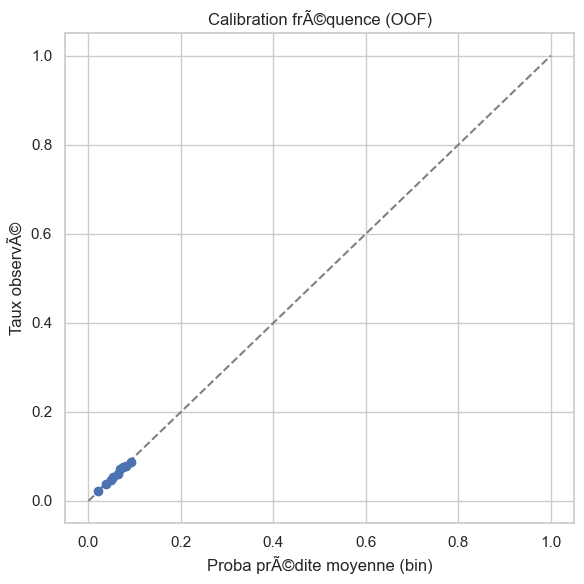

In [11]:
# Calibration frÃ©quence (reliability-like)
cal_df = diag_tables.get("calibration_freq", pd.DataFrame()) if diag_tables else pd.DataFrame()
if not cal_df.empty:
    display(cal_df)
    plt.figure(figsize=(6, 6))
    plt.plot([0,1],[0,1], '--', color='gray')
    plt.plot(cal_df["p_mean"], cal_df["y_rate"], marker='o')
    plt.xlabel("Proba prÃ©dite moyenne (bin)")
    plt.ylabel("Taux observÃ©")
    plt.title("Calibration frÃ©quence (OOF)")
    plt.tight_layout()
else:
    print("Calibration table indisponible.")


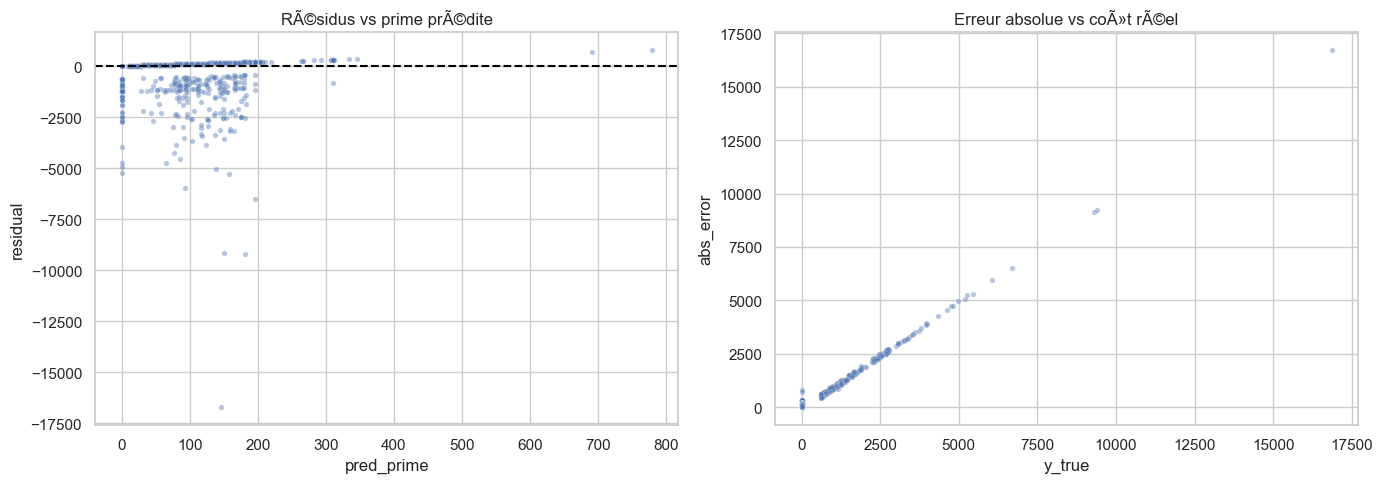

In [12]:
# Diagnostics rÃ©siduels prime
res_df = diag_tables.get("residuals", pd.DataFrame()) if diag_tables else pd.DataFrame()
if not res_df.empty:
    fig, axes = plt.subplots(1, 2, figsize=(14,5))
    sns.scatterplot(data=res_df.sample(min(len(res_df), 5000), random_state=SEED), x="pred_prime", y="residual", alpha=0.4, s=15, ax=axes[0])
    axes[0].axhline(0, ls="--", color="black")
    axes[0].set_title("RÃ©sidus vs prime prÃ©dite")
    sns.scatterplot(data=res_df.sample(min(len(res_df), 5000), random_state=SEED), x="y_true", y="abs_error", alpha=0.4, s=15, ax=axes[1])
    axes[1].set_title("Erreur absolue vs coÃ»t rÃ©el")
    plt.tight_layout()


In [13]:
# Error analysis par dÃ©ciles (rÃ©el zero-aware, positifs only, prÃ©dit)
if diag_tables:
    err_true = diag_tables.get("error_by_decile_true", pd.DataFrame())
    err_true_za = diag_tables.get("error_by_decile_true_zero_aware", pd.DataFrame())
    err_true_pos = diag_tables.get("error_by_decile_pos_only", pd.DataFrame())
    err_pred = diag_tables.get("error_by_decile_pred", pd.DataFrame())
    if not err_true.empty:
        display(err_true)
    if not err_true_za.empty:
        display(err_true_za)
    if not err_true_pos.empty:
        display(err_true_pos)
    if not err_pred.empty:
        display(err_pred)


,decile_basis,bin_type,bin_order,bin,n,y_mean,pred_mean,bias,mae,rmse
0,y_true,zero,0,zero,47083,0.000000,81.100053,81.100053,81.100053,100.615752
1,y_true,positive_decile,1,"(600.599, 698.79]",292,644.527500,99.766043,-544.761457,544.930072,550.277253
2,y_true,positive_decile,2,"(698.79, 851.978]",292,772.985342,96.150867,-676.834476,676.834476,680.605112
3,y_true,positive_decile,3,"(851.978, 1010.41]",331,957.972085,88.952121,-869.019963,869.019963,873.282006
4,y_true,positive_decile,4,"(1010.41, 1224.192]",252,1114.050952,98.798698,-1015.252255,1015.252255,1018.862386
5,y_true,positive_decile,5,"(1224.192, 1236.0]",346,1235.759364,75.905501,-1159.853863,1159.853863,1161.232854
6,y_true,positive_decile,6,"(1236.0, 1442.87]",259,1337.212664,100.502512,-1236.710152,1236.710152,1239.942841
7,y_true,positive_decile,7,"(1442.87, 1890.012]",270,1650.654889,97.246145,-1553.408744,1553.408744,1560.494063
8,y_true,positive_decile,8,"(1890.012, 2487.526]",291,2180.740722,102.991911,-2077.748810,2077.748810,2087.066466
9,y_true,positive_decile,9,"(2487.526, 3336.74]",292,2812.897260,102.709318,-2710.187943,2710.187943,2721.394782


,decile_basis,bin_type,bin_order,bin,n,y_mean,pred_mean,bias,mae,rmse
0,y_true_zero_aware,zero,0,zero,47083,0.000000,81.100053,81.100053,81.100053,100.615752
1,y_true_zero_aware,positive_decile,1,"(600.599, 698.79]",292,644.527500,99.766043,-544.761457,544.930072,550.277253
2,y_true_zero_aware,positive_decile,2,"(698.79, 851.978]",292,772.985342,96.150867,-676.834476,676.834476,680.605112
3,y_true_zero_aware,positive_decile,3,"(851.978, 1010.41]",331,957.972085,88.952121,-869.019963,869.019963,873.282006
4,y_true_zero_aware,positive_decile,4,"(1010.41, 1224.192]",252,1114.050952,98.798698,-1015.252255,1015.252255,1018.862386
5,y_true_zero_aware,positive_decile,5,"(1224.192, 1236.0]",346,1235.759364,75.905501,-1159.853863,1159.853863,1161.232854
6,y_true_zero_aware,positive_decile,6,"(1236.0, 1442.87]",259,1337.212664,100.502512,-1236.710152,1236.710152,1239.942841
7,y_true_zero_aware,positive_decile,7,"(1442.87, 1890.012]",270,1650.654889,97.246145,-1553.408744,1553.408744,1560.494063
8,y_true_zero_aware,positive_decile,8,"(1890.012, 2487.526]",291,2180.740722,102.991911,-2077.748810,2077.748810,2087.066466
9,y_true_zero_aware,positive_decile,9,"(2487.526, 3336.74]",292,2812.897260,102.709318,-2710.187943,2710.187943,2721.394782


,decile_basis,bin_type,bin_order,bin,n,y_mean,pred_mean,bias,mae,rmse
0,y_true_positive_only,qcut_all,1,"(1010.41, 1224.192]",252,1114.050952,98.798698,-1015.252255,1015.252255,1018.862386
1,y_true_positive_only,qcut_all,2,"(1224.192, 1236.0]",346,1235.759364,75.905501,-1159.853863,1159.853863,1161.232854
2,y_true_positive_only,qcut_all,3,"(1236.0, 1442.87]",259,1337.212664,100.502512,-1236.710152,1236.710152,1239.942841
3,y_true_positive_only,qcut_all,4,"(1442.87, 1890.012]",270,1650.654889,97.246145,-1553.408744,1553.408744,1560.494063
4,y_true_positive_only,qcut_all,5,"(1890.012, 2487.526]",291,2180.740722,102.991911,-2077.748810,2077.748810,2087.066466
5,y_true_positive_only,qcut_all,6,"(2487.526, 3336.74]",292,2812.897260,102.709318,-2710.187943,2710.187943,2721.394782
6,y_true_positive_only,qcut_all,7,"(3336.74, 21826.96]",292,5072.515959,103.382877,-4969.133082,4969.133082,5469.479943
7,y_true_positive_only,qcut_all,8,"(600.599, 698.79]",292,644.527500,99.766043,-544.761457,544.930072,550.277253
8,y_true_positive_only,qcut_all,9,"(698.79, 851.978]",292,772.985342,96.150867,-676.834476,676.834476,680.605112
9,y_true_positive_only,qcut_all,10,"(851.978, 1010.41]",331,957.972085,88.952121,-869.019963,869.019963,873.282006


,decile_basis,bin,n,y_mean,pred_mean,bias,mae,rmse
0,y_pred,"(-0.001, 41.433]",15023,78.446182,9.303926,-69.142256,87.320850,472.411178
1,y_pred,"(118.576, 143.301]",5019,147.580996,130.958900,-16.622096,258.553494,666.301233
2,y_pred,"(143.301, 158.623]",5207,157.176614,150.664675,-6.511940,282.442556,673.700582
3,y_pred,"(158.623, 779.006]",4767,163.791647,179.792665,16.001018,312.056212,725.289979
4,y_pred,"(41.433, 68.63]",4985,59.729575,54.020339,-5.709236,109.704778,388.852144
5,y_pred,"(68.63, 84.733]",5001,70.454621,77.449763,6.995142,140.657518,379.715944
6,y_pred,"(84.733, 96.293]",5268,94.485822,92.199702,-2.286120,176.602465,576.689071
7,y_pred,"(96.293, 118.576]",4730,106.173569,109.454032,3.280463,202.601010,508.538081


,scope,group_col,group_value,column,present_train,present_test,applicable_train,applicable_test,missing_rate_train,missing_rate_test,missing_rate_train_effective,missing_rate_test_effective,missing_rate_train_filled,missing_rate_test_filled,missing_gap_test_minus_train
292,global,None,None,sex_conducteur2,1,1,1,1,0.66812,0.66816,0.66812,0.66816,0.66812,0.66816,0.00004
269,global,None,None,anciennete_vehicule,1,1,1,1,0.00002,0.00000,0.00002,0.00000,0.00002,0.00000,-0.00002
264,global,None,None,age_conducteur1,1,1,1,1,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000
267,global,None,None,anciennete_permis1,1,1,1,1,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000
265,global,None,None,age_conducteur2,1,1,1,1,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000
268,global,None,None,anciennete_permis2,1,1,1,1,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000
270,global,None,None,bonus,1,1,1,1,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000
271,global,None,None,code_postal,1,1,1,1,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000
266,global,None,None,anciennete_info,1,1,1,1,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000
273,global,None,None,cylindre_vehicule,1,1,1,1,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000


,check,value
0,train_only_columns_count,5
1,unexpected_nan_missing_rate_test_on_present_te...,0
2,unexpected_nan_missing_rate_train_on_present_t...,0


,scope,group_col,group_value,column,present_train,present_test,applicable_train,applicable_test,missing_rate_train,missing_rate_test,missing_rate_train_effective,missing_rate_test_effective,missing_rate_train_filled,missing_rate_test_filled,missing_gap_test_minus_train
224,by_group,conducteur2,No,sex_conducteur2,1,1,1,0,1.000000,NaN,1.000000,NaN,1.000000,0.0,NaN
226,by_group,type_vehicule,Commercial,sex_conducteur2,1,1,1,0,0.787268,NaN,0.787268,NaN,0.787268,0.0,NaN
229,by_group,utilisation,Professional,sex_conducteur2,1,1,1,0,0.727025,NaN,0.727025,NaN,0.727025,0.0,NaN
230,by_group,utilisation,Retired,sex_conducteur2,1,1,1,0,0.724146,NaN,0.724146,NaN,0.724146,0.0,NaN
228,by_group,utilisation,AllTrips,sex_conducteur2,1,1,1,0,0.708333,NaN,0.708333,NaN,0.708333,0.0,NaN
227,by_group,type_vehicule,Tourism,sex_conducteur2,1,1,1,0,0.654987,NaN,0.654987,NaN,0.654987,0.0,NaN
231,by_group,utilisation,WorkPrivate,sex_conducteur2,1,1,1,0,0.638809,NaN,0.638809,NaN,0.638809,0.0,NaN
47,by_group,utilisation,WorkPrivate,anciennete_vehicule,1,1,1,0,0.000030,NaN,0.000030,NaN,0.000030,0.0,NaN
40,by_group,conducteur2,No,anciennete_vehicule,1,1,1,0,0.000030,NaN,0.000030,NaN,0.000030,0.0,NaN
43,by_group,type_vehicule,Tourism,anciennete_vehicule,1,1,1,0,0.000022,NaN,0.000022,NaN,0.000022,0.0,NaN


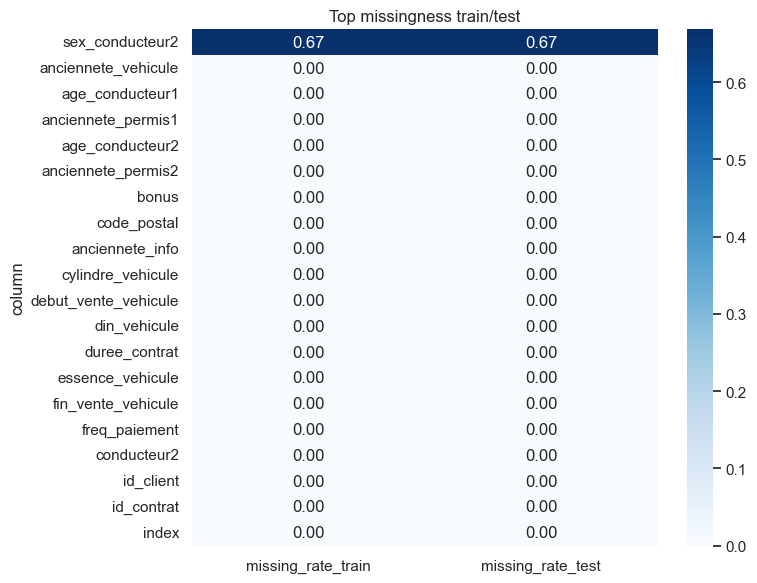

In [14]:
# Ensure datasets are loaded for quality/segment diagnostics
if 'train_raw' not in globals() or 'test_raw' not in globals():
    train_raw, test_raw = load_project_datasets(DATA_DIR)

# Missingness global + par sous-population
missing_report = compute_missingness_report(
    train_raw, test_raw, group_cols=["utilisation", "type_vehicule", "conducteur2"]
)

missing_global = missing_report[missing_report["scope"] == "global"].copy()

# --- Backward/forward compatible: ensure *_filled exists ---
def _ensure_filled(df, preferred_base_cols, filled_col):
    if filled_col in df.columns:
        return df
    base_col = next((c for c in preferred_base_cols if c in df.columns), None)
    if base_col is None:
        raise KeyError(
            f"Impossible de crÃ©er {filled_col}. Colonnes dispo: {list(df.columns)}"
        )
    s = df[base_col]

    # Si les taux sont en [0,1] -> fill=1.0 ; si en % -> fill=100.0
    mx = s.dropna().max() if s.notna().any() else 1.0
    fill_val = 100.0 if mx > 1.5 else 1.0

    df[filled_col] = s.fillna(fill_val)
    return df

missing_global = _ensure_filled(
    missing_global,
    preferred_base_cols=["missing_rate_train_effective", "missing_rate_train"],
    filled_col="missing_rate_train_filled",
)
missing_global = _ensure_filled(
    missing_global,
    preferred_base_cols=["missing_rate_test_effective", "missing_rate_test"],
    filled_col="missing_rate_test_filled",
)

# Tri + affichage
missing_global = missing_global.sort_values("missing_rate_train_filled", ascending=False)
display(missing_global.head(20))

# QC (robuste si les colonnes existent)
missing_qc = pd.DataFrame([
    {
        "check": "train_only_columns_count",
        "value": int(((missing_global["present_train"] == 1) & (missing_global["present_test"] == 0)).sum()),
    },
    {
        "check": "unexpected_nan_missing_rate_test_on_present_test_cols",
        "value": int(
            missing_global.loc[missing_global["present_test"] == 1,
                               "missing_rate_test_effective"].isna().sum()
        ) if "missing_rate_test_effective" in missing_global.columns else 0,
    },
    {
        "check": "unexpected_nan_missing_rate_train_on_present_train_cols",
        "value": int(
            missing_global.loc[missing_global["present_train"] == 1,
                               "missing_rate_train_effective"].isna().sum()
        ) if "missing_rate_train_effective" in missing_global.columns else 0,
    },
])
display(missing_qc)

pivot_missing = (
    missing_global[["column","missing_rate_train_filled","missing_rate_test_filled"]]
    .rename(columns={"missing_rate_train_filled":"missing_rate_train", "missing_rate_test_filled":"missing_rate_test"})
    .set_index("column")
    .sort_values("missing_rate_train", ascending=False)
    .head(20)
)

plt.figure(figsize=(8, 6))
sns.heatmap(pivot_missing, annot=True, fmt=".2f", cmap="Blues")
plt.title("Top missingness train/test")
plt.tight_layout()

missing_group = missing_report[missing_report["scope"] == "by_group"].copy()
# (si ta fonction renvoie missing_rate_train_filled/by_group diffÃ©remment, adapte ici pareil)
display(missing_group.sort_values("missing_rate_train", ascending=False).head(20))

In [15]:
# ExtrÃªmes (top 1% coÃ»ts rÃ©els et grosses erreurs)
if diag_tables and "residuals" in diag_tables and len(diag_tables["residuals"]):
    res_df = diag_tables["residuals"].copy()
    extreme_summary_df = diag_tables.get("extreme_cases_summary", pd.DataFrame())
    if not extreme_summary_df.empty:
        display(extreme_summary_df)
    q99_true = res_df["y_true"].quantile(0.99)
    extreme_true = res_df[res_df["y_true"] >= q99_true].sort_values("y_true", ascending=False).head(20)
    extreme_err = res_df.sort_values("abs_error", ascending=False).head(20)
    print("Top 1% coÃ»ts rÃ©els")
    display(extreme_true)
    print("Plus grosses erreurs absolues")
    display(extreme_err)


,subset,n,share,y_mean,pred_mean,mae,rmse,q95_abs_error,max_abs_error
0,all,50000,1.00000,103.369344,81.973629,174.134052,545.929482,670.129183,21732.277757
1,true_top1pct,503,0.01006,4164.475785,103.396906,4061.078879,4548.227515,7174.679385,21732.277757
2,nonzero_only,2917,0.05834,1771.843401,96.073926,1675.786354,2223.792546,4241.802000,21732.277757


Top 1% coÃ»ts rÃ©els


,row_idx,y_true,y_freq,pred_freq,pred_sev,pred_prime,residual,abs_error,sq_error,is_extreme_true_top1,is_nonzero_true,decile_true_zero_aware_bucket
1923265,23265,21826.96,1.0,0.053848,1758.316205,94.682243,-21732.277757,21732.277757,4.722919e+08,1,1,"positive_decile:(3336.74, 21826.96]"
1902408,2408,18246.90,1.0,0.064497,0.000000,0.000000,-18246.900000,18246.900000,3.329494e+08,1,1,"positive_decile:(3336.74, 21826.96]"
1927721,27721,16859.40,1.0,0.079065,1842.270131,145.658868,-16713.741132,16713.741132,2.793491e+08,1,1,"positive_decile:(3336.74, 21826.96]"
1912864,12864,15997.50,1.0,0.093048,1843.351791,171.520434,-15825.979566,15825.979566,2.504616e+08,1,1,"positive_decile:(3336.74, 21826.96]"
1938429,38429,13813.54,1.0,0.048603,1840.500264,89.454482,-13724.085518,13724.085518,1.883505e+08,1,1,"positive_decile:(3336.74, 21826.96]"
1924967,24967,12069.04,1.0,0.033027,1377.437436,45.491978,-12023.548022,12023.548022,1.445657e+08,1,1,"positive_decile:(3336.74, 21826.96]"
1927492,27492,11906.24,1.0,0.068804,1758.316205,120.978754,-11785.261246,11785.261246,1.388924e+08,1,1,"positive_decile:(3336.74, 21826.96]"
1927763,27763,11724.25,1.0,0.079065,2061.604824,163.000539,-11561.249461,11561.249461,1.336625e+08,1,1,"positive_decile:(3336.74, 21826.96]"
1925981,25981,11509.30,1.0,0.077841,1935.638657,150.672443,-11358.627557,11358.627557,1.290184e+08,1,1,"positive_decile:(3336.74, 21826.96]"
1931573,31573,11484.16,1.0,0.090628,1886.958511,171.011087,-11313.148913,11313.148913,1.279873e+08,1,1,"positive_decile:(3336.74, 21826.96]"


Plus grosses erreurs absolues


,row_idx,y_true,y_freq,pred_freq,pred_sev,pred_prime,residual,abs_error,sq_error,is_extreme_true_top1,is_nonzero_true,decile_true_zero_aware_bucket
1923265,23265,21826.96,1.0,0.053848,1758.316205,94.682243,-21732.277757,21732.277757,4.722919e+08,1,1,"positive_decile:(3336.74, 21826.96]"
1902408,2408,18246.90,1.0,0.064497,0.000000,0.000000,-18246.900000,18246.900000,3.329494e+08,1,1,"positive_decile:(3336.74, 21826.96]"
1927721,27721,16859.40,1.0,0.079065,1842.270131,145.658868,-16713.741132,16713.741132,2.793491e+08,1,1,"positive_decile:(3336.74, 21826.96]"
1912864,12864,15997.50,1.0,0.093048,1843.351791,171.520434,-15825.979566,15825.979566,2.504616e+08,1,1,"positive_decile:(3336.74, 21826.96]"
1938429,38429,13813.54,1.0,0.048603,1840.500264,89.454482,-13724.085518,13724.085518,1.883505e+08,1,1,"positive_decile:(3336.74, 21826.96]"
1924967,24967,12069.04,1.0,0.033027,1377.437436,45.491978,-12023.548022,12023.548022,1.445657e+08,1,1,"positive_decile:(3336.74, 21826.96]"
1927492,27492,11906.24,1.0,0.068804,1758.316205,120.978754,-11785.261246,11785.261246,1.388924e+08,1,1,"positive_decile:(3336.74, 21826.96]"
1927763,27763,11724.25,1.0,0.079065,2061.604824,163.000539,-11561.249461,11561.249461,1.336625e+08,1,1,"positive_decile:(3336.74, 21826.96]"
1925981,25981,11509.30,1.0,0.077841,1935.638657,150.672443,-11358.627557,11358.627557,1.290184e+08,1,1,"positive_decile:(3336.74, 21826.96]"
1931573,31573,11484.16,1.0,0.090628,1886.958511,171.011087,-11313.148913,11313.148913,1.279873e+08,1,1,"positive_decile:(3336.74, 21826.96]"


In [16]:
# Feature importance fallback (sans SHAP) : permutation importance sur modÃ¨le proxy
try:
    from sklearn.ensemble import RandomForestRegressor
    from sklearn.inspection import permutation_importance
    from src.insurance_pricing.analytics.segmentation import _prepare_mixed_matrix
    train_raw, _ = load_project_datasets(DATA_DIR)
    bundles = v2.prepare_feature_sets(train_raw, test_raw if 'test_raw' in globals() else load_project_datasets(DATA_DIR)[1], rare_min_count=30, drop_identifiers=True)
    b = bundles["robust_v2"]
    X = b.X_train.copy()
    y = b.y_sev.to_numpy(dtype=float)
    n_fit = 6000 if QUICK_ANALYSIS else min(len(X), 20000)
    idx = np.random.RandomState(SEED).choice(len(X), size=n_fit, replace=False)
    Xs = X.iloc[idx].copy()
    ys = y[idx]
    num_cols = [c for c in Xs.columns if c in b.num_cols]
    cat_cols = [c for c in Xs.columns if c in b.cat_cols]
    Xmat, feat_names = _prepare_mixed_matrix(Xs, num_cols=num_cols, cat_cols=cat_cols)
    rf = RandomForestRegressor(n_estimators=80 if QUICK_ANALYSIS else 150, random_state=SEED, n_jobs=-1, max_depth=10)
    rf.fit(Xmat, ys)
    pi = permutation_importance(rf, Xmat, ys, n_repeats=3 if QUICK_ANALYSIS else 5, random_state=SEED, n_jobs=1)
    pi_df = pd.DataFrame({"feature": feat_names, "importance_mean": pi.importances_mean, "importance_std": pi.importances_std}).sort_values("importance_mean", ascending=False)
    display(pi_df.head(30))
except Exception as e:
    print("Permutation importance fallback indisponible:", type(e).__name__, e)


,feature,importance_mean,importance_std
475,cat__cp3_683,0.151034,0.008184
7,num__anciennete_vehicule,0.104844,0.008466
12,num__vitesse_vehicule,0.070726,0.002486
479,cat__cp3_693,0.069889,0.002867
284,cat__cp3_261,0.046271,0.004079
547,cat__cp3_892,0.036648,0.003468
4,num__age_conducteur2,0.033200,0.002815
6,num__anciennete_permis2,0.029312,0.001377
10,num__debut_vente_vehicule,0.024040,0.001692
35,cat__freq_paiement_Quarterly,0.023547,0.001685


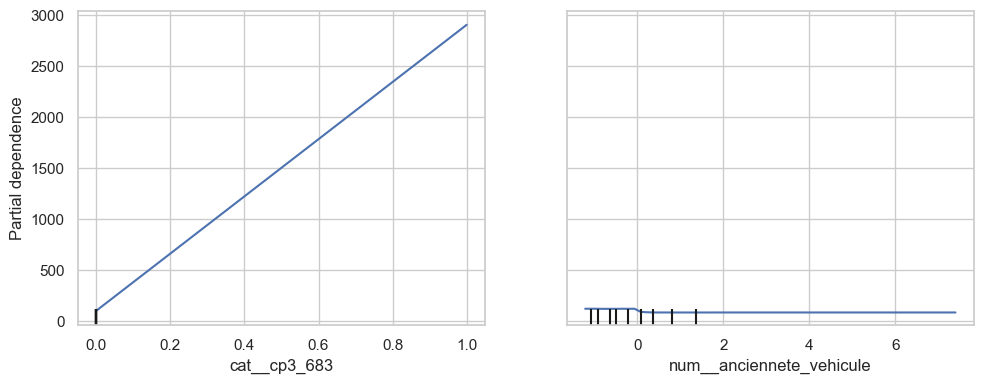

In [17]:
# PDP/ICE (optionnel, fallback safe)
try:
    from sklearn.inspection import PartialDependenceDisplay
    # Si la cellule prÃ©cÃ©dente a crÃ©Ã© rf/Xmat/feat_names
    if "rf" in globals() and "Xmat" in globals() and "feat_names" in globals():
        top_idx = list(np.argsort(-np.asarray(pi.importances_mean))[:2]) if "pi" in globals() else [0, 1]
        fig, ax = plt.subplots(figsize=(10,4))
        PartialDependenceDisplay.from_estimator(rf, Xmat, features=top_idx, feature_names=feat_names, ax=ax)
        plt.tight_layout()
    else:
        print("ModÃ¨le proxy indisponible.")
except Exception as e:
    print("PDP/ICE non disponible:", type(e).__name__, e)


## SHAP (section optionnelle)

- Si `shap` est installÃ©: produire une analyse globale + locale sur un sous-Ã©chantillon.
- Sinon: conserver permutation importance + PDP/ICE comme fallback.

**DÃ©cision pratique**: dans ce repo, `shap` n'est pas une dÃ©pendance obligatoire.


In [18]:
# StabilitÃ© des features importantes selon folds / seeds (proxy via runs V2 + catÃ©gories)
if not run_df.empty:
    cols = [c for c in ["engine","family","feature_set","seed","split","rmse_prime","q99_ratio_pos"] if c in run_df.columns]
    stability_view = run_df[cols].copy()
    summary = stability_view.groupby(["engine","family","feature_set","split"]).agg(
        n_runs=("rmse_prime","size"),
        rmse_mean=("rmse_prime","mean"),
        rmse_std=("rmse_prime","std"),
        q99_mean=("q99_ratio_pos","mean"),
    ).reset_index()
    display(summary.sort_values(["split","rmse_mean"]).head(30))


,engine,family,feature_set,split,n_runs,rmse_mean,rmse_std,q99_mean
6,catboost,two_part_tweedie,base_v2,aux_blocked5,4,542.588534,0.018556,0.291046
3,catboost,two_part_classic,base_v2,aux_blocked5,4,542.626976,0.056627,0.296188
24,xgboost,two_part_tweedie,base_v2,aux_blocked5,4,542.863905,0.025150,0.295572
21,xgboost,two_part_classic,base_v2,aux_blocked5,4,542.865231,0.020536,0.293026
0,catboost,direct_tweedie,base_v2,aux_blocked5,1,542.958342,NaN,0.333277
12,lightgbm,two_part_classic,base_v2,aux_blocked5,4,543.143219,0.125282,0.288097
15,lightgbm,two_part_tweedie,base_v2,aux_blocked5,4,543.145551,0.095934,0.287002
18,xgboost,direct_tweedie,base_v2,aux_blocked5,1,543.417720,NaN,0.314290
9,lightgbm,direct_tweedie,base_v2,aux_blocked5,1,543.817164,NaN,0.326298
7,catboost,two_part_tweedie,base_v2,primary_time,4,544.244949,0.336002,0.324925


In [19]:
# Shake-up public/private (standard + tail stratified)
for name in ["shakeup_v2_ensemble.parquet", "shakeup_v2_ensemble_tail.parquet", "shakeup_v2_single.parquet"]:
    p = ARTIFACT_V2 / name
    if p.exists():
        sh = pd.read_parquet(p)
        print(name, sh.shape)
        display(sh.describe())


shakeup_v2_ensemble.parquet (2000, 5)


,sim_id,rmse_public,rmse_private,gap_public_minus_private,stratified_tail
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.0
mean,999.500000,544.670142,546.046845,-1.376703,0.0
std,577.494589,23.992074,12.024106,36.008336,0.0
min,0.000000,470.048069,505.094513,-110.004223,0.0
25%,499.750000,528.181700,538.257306,-26.295018,0.0
50%,999.500000,544.246099,546.653655,-2.407556,0.0
75%,1499.250000,560.733316,554.476718,22.476010,0.0
max,1999.000000,619.371211,580.052293,114.276699,0.0


shakeup_v2_ensemble_tail.parquet (2000, 5)


,sim_id,rmse_public,rmse_private,gap_public_minus_private,stratified_tail
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.0
mean,999.500000,544.710052,545.767261,-1.057208,1.0
std,577.494589,37.661792,7.645607,45.297157,0.0
min,0.000000,436.125327,514.960229,-129.123901,1.0
25%,499.750000,518.143547,541.166254,-33.083900,1.0
50%,999.500000,541.750043,546.669135,-4.919092,1.0
75%,1499.250000,568.701492,551.227447,27.535238,1.0
max,1999.000000,679.553153,565.249228,164.592924,1.0


shakeup_v2_single.parquet (2000, 5)


,sim_id,rmse_public,rmse_private,gap_public_minus_private,stratified_tail
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.0
mean,999.500000,544.745310,546.125426,-1.380116,0.0
std,577.494589,23.981820,12.018969,35.992958,0.0
min,0.000000,470.139310,505.275723,-109.984960,0.0
25%,499.750000,528.235635,538.362119,-26.329367,0.0
50%,999.500000,544.348243,546.718409,-2.370166,0.0
75%,1499.250000,560.757492,554.565002,22.395373,0.0
max,1999.000000,619.279680,580.124270,114.003957,0.0


## ContrÃ´les anti-fuite (checklist explicite)

- [ ] `index` / IDs exclus comme features brutes
- [ ] target encoding uniquement fit sur train fold (cross-fit)
- [ ] validation `GroupKFold(id_client)` pour anti-fuite client
- [ ] contrÃ´le OOD train/test (nouvelles modalitÃ©s, drift)
- [ ] garde-fous sur la queue de sÃ©vÃ©ritÃ© / collapse de distribution

**DÃ©cision pratique**: cette checklist doit Ãªtre prÃ©sentÃ©e explicitement en soutenance.


In [20]:
# SynthÃ¨se business (classes de risque, quantiles, segments)
train_raw, test_raw = load_project_datasets(DATA_DIR)
y = train_raw[v2.TARGET_SEV_COL].astype(float)
risk_class = pd.qcut(y.rank(method="first"), q=5, labels=["Q1","Q2","Q3","Q4","Q5"])
business_table = pd.DataFrame({"y": y, "risk_class": risk_class}).groupby("risk_class").agg(
    n=("y","size"),
    mean_cost=("y","mean"),
    median_cost=("y","median"),
    q95=("y", lambda s: float(np.quantile(s, 0.95))),
    q99=("y", lambda s: float(np.quantile(s, 0.99))),
).reset_index()
display(business_table)


,risk_class,n,mean_cost,median_cost,q95,q99
0,Q1,10000,0.00000,0.0,0.00,0.0000
1,Q2,10000,0.00000,0.0,0.00,0.0000
2,Q3,10000,0.00000,0.0,0.00,0.0000
3,Q4,10000,0.00000,0.0,0.00,0.0000
4,Q5,10000,516.84672,0.0,2683.76,4949.4405


## Limites & risques (Ã  complÃ©ter)

- `Constat`: score public != score privÃ© (seulement 1/3 public)
- `InterprÃ©tation`: sÃ©lection opportuniste sur public trÃ¨s risquÃ©e
- `DÃ©cision`: piloter les soumissions par robustesse locale (multi-splits + shake-up)

Limites typiques Ã  mentionner:
- OOD catÃ©goriel
- queue lourde / Ã©vÃ©nements rares
- bruit cible et variables proxy imparfaites


## DÃ©cisions finales de modÃ©lisation (Ã  synthÃ©tiser)

Ã€ remplir explicitement:
- Pourquoi **frÃ©quence + sÃ©vÃ©ritÃ©** et pas seulement un modÃ¨le direct
- Pourquoi ces **splits** de CV
- Pourquoi `log1p` / Tweedie / tail mapping safe
- Pourquoi single model vs ensemble (selon stabilitÃ©)


In [21]:
# Exports diagnostics notebook 3 + storytelling summary
if diag_tables:
    export_tables = {}
    for k, v in diag_tables.items():
        if isinstance(v, pd.DataFrame):
            export_tables[f"oof_model_diagnostics_{k}"] = v
    if "diag_compare_df" in globals() and isinstance(diag_compare_df, pd.DataFrame) and len(diag_compare_df):
        export_tables["oof_model_diagnostics_compare_runs"] = diag_compare_df
    if export_tables:
        export_analysis_tables(export_tables, ARTIFACT_DS)

# storytelling summary auto-rempli avec mÃ©triques rÃ©elles + top drifts + segments
metrics_df = diag_tables.get("metrics", pd.DataFrame()) if diag_tables else pd.DataFrame()
m0 = metrics_df.iloc[0].to_dict() if isinstance(metrics_df, pd.DataFrame) and len(metrics_df) else {}
drift_num_ds = pd.read_csv(ARTIFACT_DS / "drift_numeric_ks_psi.csv") if (ARTIFACT_DS / "drift_numeric_ks_psi.csv").exists() else pd.DataFrame()
drift_cat_ds = pd.read_csv(ARTIFACT_DS / "drift_categorical_chi2.csv") if (ARTIFACT_DS / "drift_categorical_chi2.csv").exists() else pd.DataFrame()
top_num_lines = []
if len(drift_num_ds):
    cols = [c for c in ["column","psi","ks_stat","ks_pvalue"] if c in drift_num_ds.columns]
    for _, r in drift_num_ds.head(3)[cols].iterrows():
        top_num_lines.append(f"- {r.get('column')}: PSI={r.get('psi', np.nan):.3f}, KS={r.get('ks_stat', np.nan):.3f}")
top_cat_lines = []
if len(drift_cat_ds):
    cols = [c for c in ["column","unseen_ratio_test","chi2_pvalue"] if c in drift_cat_ds.columns]
    for _, r in drift_cat_ds.head(3)[cols].iterrows():
        unseen = r.get("unseen_ratio_test", np.nan)
        top_cat_lines.append(f"- {r.get('column')}: unseen_test_ratio={unseen:.3f}" if pd.notna(unseen) else f"- {r.get('column')}")

top_seg_lines = []
if 'seg_err_tables' in globals() and isinstance(seg_err_tables, dict):
    for seg_name, seg_df in list(seg_err_tables.items())[:3]:
        if isinstance(seg_df, pd.DataFrame) and len(seg_df):
            row = seg_df.iloc[0]
            key_col = seg_df.columns[0]
            top_seg_lines.append(f"- {seg_name}: segment {key_col}={row[key_col]} (n={int(row['n'])}, mae={float(row['mae']):.2f})")
if not top_seg_lines:
    top_seg_lines = ["- Ã€ complÃ©ter aprÃ¨s exÃ©cution de la cellule d'analyse segmentaire."] 

storytelling_md = ARTIFACT_DS / "storytelling_summary.md"
summary_lines = [
    "# Storytelling summary (auto + complÃ©ment manuel)",
    "",
    "## 1) Run diagnostiquÃ©",
    f"- run_id: {run_id_main}",
    f"- split: primary_time",
]
if m0:
    summary_lines.extend(
        [
            "",
            "## 2) MÃ©triques OOF (primary_time)",
            f"- RMSE prime: {float(m0.get('rmse_prime', np.nan)):.3f}",
            f"- MAE prime: {float(m0.get('mae_prime', np.nan)):.3f}",
            f"- RMSE prime top1%: {float(m0.get('rmse_prime_top1pct', np.nan)):.3f}",
            f"- AUC frÃ©quence: {float(m0.get('auc_freq', np.nan)):.4f}",
            f"- Brier frÃ©quence: {float(m0.get('brier_freq', np.nan)):.6f}",
            f"- q95_ratio_pos: {float(m0.get('q95_ratio_pos', np.nan)):.3f}",
            f"- q99_ratio_pos: {float(m0.get('q99_ratio_pos', np.nan)):.3f}",
        ]
    )
summary_lines.extend(
    [
        "",
        "## 3) Top drifts numÃ©riques (hors IDs/targets)",
        *(top_num_lines if top_num_lines else ["- N/A (artefact drift absent)"]),
        "",
        "## 4) Top drifts catÃ©goriels",
        *(top_cat_lines if top_cat_lines else ["- N/A (artefact drift absent)"]),
        "",
        "## 5) Segments Ã  risque (MAE Ã©levÃ©)",
        *top_seg_lines,
        "",
        "## 6) Limites principales",
        "- OOD catÃ©goriel sur granularitÃ© fine (ex. code postal / modÃ¨le).",
        "- Queue lourde des sinistres: le score dÃ©pend fortement de peu d'observations extrÃªmes.",
        "- Score public Kaggle potentiellement instable vs privÃ© (1/3 seulement en public).",
        "",
        "## 7) Ã€ complÃ©ter manuellement (oral)",
        "- Message business principal (compÃ©titivitÃ© vs robustesse).",
        "- Pourquoi ce run final et pas les alternatives.",
        "- Prochaines expÃ©riences V3 (rÃ©sidu vÃ©hicule / interactions ciblÃ©es).",
        "",
    ]
)
storytelling_md.write_text("\n".join(summary_lines), encoding="utf-8")
print("Exports DS notebook 3 ->", ARTIFACT_DS)
print("Storytelling summary:", storytelling_md)


Exports DS notebook 3 -> C:\Users\icemo\Downloads\Calcul-prime-d-assurance\artifacts\ds
Storytelling summary: C:\Users\icemo\Downloads\Calcul-prime-d-assurance\artifacts\ds\storytelling_summary.md


## Conclusion soutenance (10 points Ã  dire oralement)

1. Le problÃ¨me est un problÃ¨me de **tarification** avec coÃ»t d'erreur asymÃ©trique (RMSE pertinent).
2. La dÃ©composition **frÃ©quence Ã— sÃ©vÃ©ritÃ©** est standard actuarielle et explicable.
3. La sÃ©vÃ©ritÃ© prÃ©sente une **queue lourde**, donc les choix de transformation et de robustesse sont centraux.
4. Le dataset montre du **drift/OOD** sur certaines catÃ©gories fines.
5. Le split `GroupKFold(id_client)` est indispensable pour Ã©viter la fuite client.
6. Les scores sont pilotÃ©s par **OOF multi-splits**, pas par un seul score public Kaggle.
7. La calibration frÃ©quence compte car la prime finale multiplie probabilitÃ© Ã— montant.
8. L'analyse d'erreurs par segments et dÃ©ciles rÃ©vÃ¨le oÃ¹ le modÃ¨le sous-/sur-tarife.
9. Les contrÃ´les anti-fuite et anti-collapse de distribution sont intÃ©grÃ©s Ã  la dÃ©marche.
10. La stratÃ©gie de soumission privilÃ©gie la **robustesse privÃ©e** plutÃ´t que l'optimisation opportuniste du public.


## Export standardis? des sorties DS (CSV + PNG)

Cette cellule sauvegarde les tables et figures dans `artifacts/ds/` via `ds_reporting`.


In [22]:
# DS_OUTPUT_EXPORT_CELL_V1
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
from src.insurance_pricing.runtime.ds_reporting import save_table, save_figure, export_ds_tables_and_figures

NOTEBOOK_NAME = '09_ds_model_diagnostics_storytelling.ipynb'
DS_ROOT = Path('artifacts/ds')

# Export tables disponibles (compat notebooks existants)
for csv_path in sorted(DS_ROOT.glob('*.csv')):
    try:
        df = pd.read_csv(csv_path)
        save_table(df, csv_path.stem, NOTEBOOK_NAME)
    except Exception:
        pass

# Figure l?g?re de synth?se (si m?triques dispo)
metrics_path = DS_ROOT / 'oof_model_diagnostics_metrics.csv'
if metrics_path.exists():
    m = pd.read_csv(metrics_path)
    if not m.empty and 'q99_ratio_pos' in m.columns:
        fig, ax = plt.subplots(figsize=(7, 3.5))
        q = pd.to_numeric(m['q99_ratio_pos'], errors='coerce').dropna()
        if len(q):
            ax.plot(range(len(q)), q, marker='o')
            ax.axhline(1.0, linestyle='--', color='red', linewidth=1)
            ax.set_title('q99_ratio_pos - diagnostic')
            ax.set_xlabel('run')
            ax.set_ylabel('ratio')
            save_figure(fig, 'q99_ratio_pos_notebook', NOTEBOOK_NAME, dpi=160)
        plt.close(fig)

# Export batch standardis?
_ = export_ds_tables_and_figures(mode='full')
print('DS exports updated for', NOTEBOOK_NAME)



DS exports updated for 09_ds_model_diagnostics_storytelling.ipynb
